In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report



In [22]:
# Load the dataset
df = pd.read_csv(r"C:\Users\NAMAN\Downloads\archive\Plant_1_Generation_Data.csv")

# Convert DATE_TIME column to datetime type
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])

# Drop non-numeric ID columns (not useful for regression)
df = df.drop(columns=['PLANT_ID', 'SOURCE_KEY'])

# Quick check
df.head()

C:\Users\NAMAN\AppData\Local\Temp\ipykernel_12308\942621395.py:5: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])


,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15,0.0,0.0,0.0,6259559.0
1,2020-05-15,0.0,0.0,0.0,6183645.0
2,2020-05-15,0.0,0.0,0.0,6987759.0
3,2020-05-15,0.0,0.0,0.0,7602960.0
4,2020-05-15,0.0,0.0,0.0,7158964.0


In [23]:
# Dataset info
print(df.info())

# Summary statistics
print(df.describe())

# Check missing values
print("Missing values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE_TIME    68778 non-null  datetime64[ns]
 1   DC_POWER     68778 non-null  float64       
 2   AC_POWER     68778 non-null  float64       
 3   DAILY_YIELD  68778 non-null  float64       
 4   TOTAL_YIELD  68778 non-null  float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 2.6 MB
None
                           DATE_TIME      DC_POWER      AC_POWER  \
count                          68778  68778.000000  68778.000000   
mean   2020-06-01 08:02:49.458256896   3147.426211    307.802752   
min              2020-05-15 00:00:00      0.000000      0.000000   
25%              2020-05-24 00:45:00      0.000000      0.000000   
50%              2020-06-01 14:30:00    429.000000     41.493750   
75%              2020-06-09 20:00:00   6366.964286    623.618750   
max      

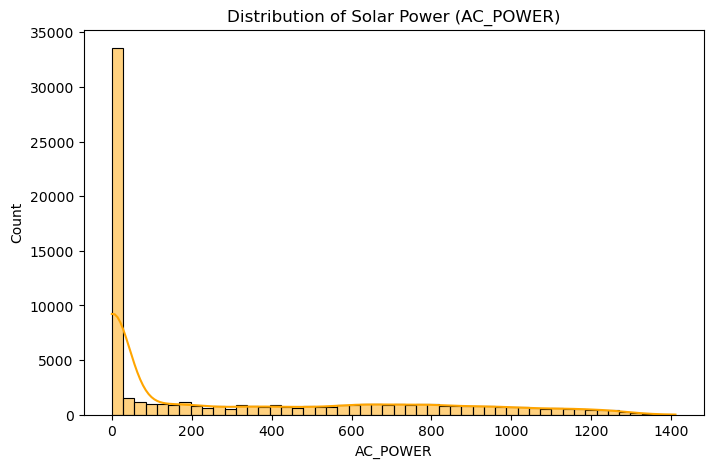

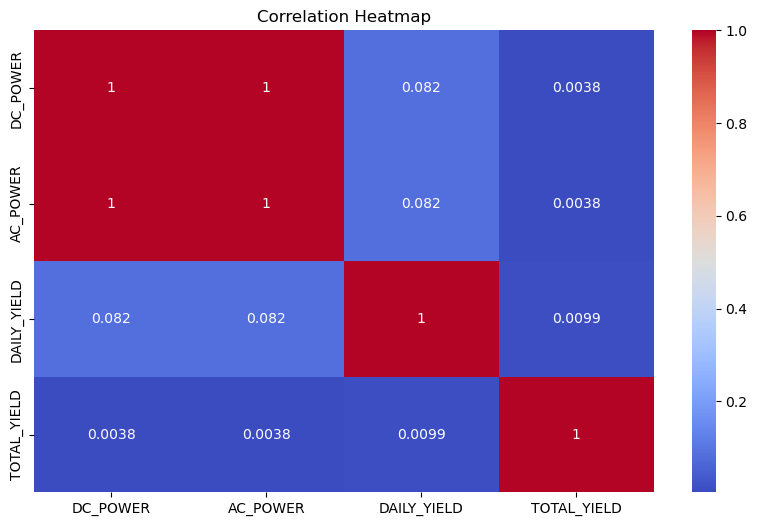

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df['AC_POWER'], bins=50, kde=True, color="orange")
plt.title("Distribution of Solar Power (AC_POWER)")
plt.show()

# Correlation Heatmap (numeric columns only)
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [25]:
# Extract time-based features
df['hour'] = df['DATE_TIME'].dt.hour
df['day'] = df['DATE_TIME'].dt.day
df['month'] = df['DATE_TIME'].dt.month

# Define features and target
X = df.drop(columns=['AC_POWER', 'DATE_TIME'])
y = df['AC_POWER']

X.head()

,DC_POWER,DAILY_YIELD,TOTAL_YIELD,hour,day,month
0,0.0,0.0,6259559.0,0,15,5
1,0.0,0.0,6183645.0,0,15,5
2,0.0,0.0,6987759.0,0,15,5
3,0.0,0.0,7602960.0,0,15,5
4,0.0,0.0,7158964.0,0,15,5


In [26]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [29]:
# Make predictions
y_pred = model.predict(X_test_scaled)

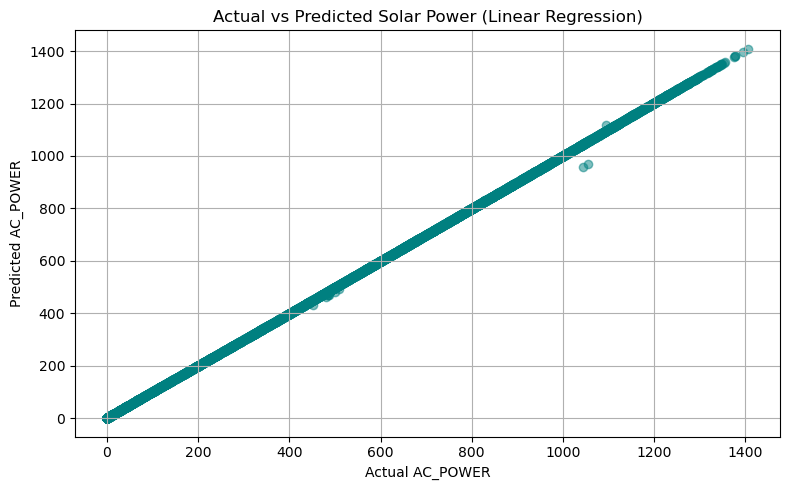

In [30]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.title("Actual vs Predicted Solar Power (Linear Regression)")
plt.xlabel("Actual AC_POWER")
plt.ylabel("Predicted AC_POWER")
plt.grid(True)
plt.tight_layout()
plt.show()


In [31]:
def power_to_class(power):
    if power < 50:
        return 0  # Low Power
    elif power < 200:
        return 1  # Medium Power
    else:
        return 2  # High Power

# Apply function to true and predicted values
true_labels = y_test.apply(power_to_class)
predicted_labels = pd.Series(y_pred).apply(power_to_class)



Confusion Matrix:
 [[7031    3    0]
 [   0 1015    0]
 [   0    2 5705]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      7034
           1       1.00      1.00      1.00      1015
           2       1.00      1.00      1.00      5707

    accuracy                           1.00     13756
   macro avg       1.00      1.00      1.00     13756
weighted avg       1.00      1.00      1.00     13756



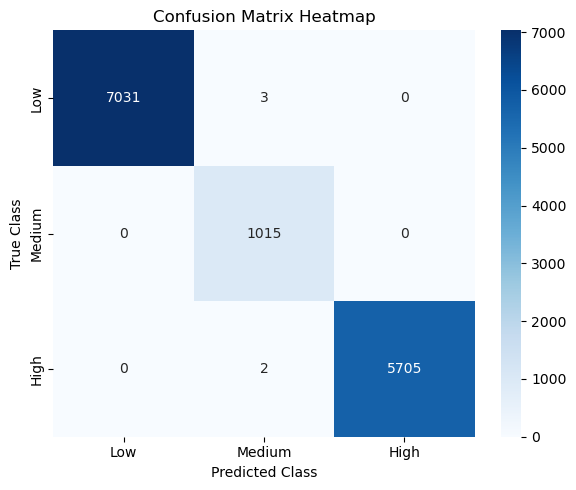

In [32]:
# Confusion Matrix & Classification Report
cm = confusion_matrix(true_labels, predicted_labels)
cr = classification_report(true_labels, predicted_labels)

print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", cr)

# Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', 
    xticklabels=['Low', 'Medium', 'High'], 
    yticklabels=['Low', 'Medium', 'High']
)
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()
